# MScFE 652 Portfolio Management — Group Work Project #2
## Group 13319 | Corrected & Annotated Version
**Members:** Innocent Ndagijimana · Samiramis Khazaei · Sehinde Oduntan Odesina

---
## Setup: Imports and Libraries

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Data
import yfinance as yf

# Optimisation
from scipy.optimize import minimize
import cvxpy as cp

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Statistics
from scipy.stats import skew, kurtosis

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Part 1 — Mean-Variance Optimisation
### Step 0: Data Download & Descriptive Statistics

In [3]:
# ---------------------------------------------------------------
# Download daily adjusted closing prices for the 7 assets
# Period: 1 Jan 2023 – 30 Jun 2025  |  622 trading observations
# ---------------------------------------------------------------
TICKERS   = ['AAPL', 'NVDA', 'TSLA', 'XOM', 'REGN', 'LLY', 'JPM']
START     = '2023-01-01'
END       = '2025-06-30'
TRADING_DAYS = 252   # annualisation factor
RF_ANN    = 0.0423   # 13-week T-bill rate as of mid-2025

raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True)['Close']
raw = raw[TICKERS]   # enforce consistent column order

# Log returns:  r_t = ln(P_t / P_{t-1})
# Log returns are time-additive and approximately Gaussian, making them
# the appropriate input for MVO.
log_ret = np.log(raw / raw.shift(1)).dropna()

print(f'Observations: {len(log_ret)} trading days ({START} to {END})')
print(log_ret.head())

[*********************100%***********************]  7 of 7 completed

Observations: 622 trading days (2023-01-01 to 2025-06-30)
Ticker          AAPL      NVDA      TSLA       XOM      REGN       LLY  \
Date                                                                     
2023-01-04  0.010261  0.029867  0.049979  0.002906  0.008321 -0.005192   
2023-01-05 -0.010661 -0.033366 -0.029469  0.022128 -0.003765 -0.011579   
2023-01-06  0.036134  0.040797  0.024352  0.012014  0.018332  0.011138   
2023-01-09  0.004080  0.050458  0.057655 -0.018813 -0.079978 -0.036790   
2023-01-10  0.004447  0.017821 -0.007711  0.014824  0.026766  0.008312   

Ticker           JPM  
Date                  
2023-01-04  0.009282  
2023-01-05 -0.000221  
2023-01-06  0.018955  
2023-01-09 -0.004141  
2023-01-10  0.008914  


In [4]:
# ---------------------------------------------------------------
# Compute and annualise descriptive statistics
# ---------------------------------------------------------------
stats = pd.DataFrame(index=TICKERS)
stats['Ann. Return (%)']  = log_ret.mean() * TRADING_DAYS * 100
stats['Volatility (%)']   = log_ret.std()  * np.sqrt(TRADING_DAYS) * 100
stats['Skewness']         = log_ret.apply(lambda x: skew(x))
stats['Ex. Kurtosis']     = log_ret.apply(lambda x: kurtosis(x, fisher=True))
# Report uses rf=0 for the Sharpe column (labelled "Sharpe (rf=0)")
stats['Sharpe (rf=0)']    = stats['Ann. Return (%)'] / stats['Volatility (%)']

print('Table 1: Descriptive Statistics — Daily Log Returns, Annualised (Jan 2023 – Jun 2025)')
print(stats.round(2).to_string())


Table 1: Descriptive Statistics — Daily Log Returns, Annualised (Jan 2023 – Jun 2025)
      Ann. Return (%)  Volatility (%)  Skewness  Ex. Kurtosis  Sharpe (rf=0)
AAPL            19.76           26.22      0.49         11.78           0.75
NVDA            97.26           52.47      0.39          6.11           1.85
TSLA            44.43           61.88      0.28          3.32           0.72
XOM              4.53           23.42     -0.32          1.89           0.19
REGN           -13.02           30.22     -2.68         26.94          -0.43
LLY             31.34           32.62      0.41          8.54           0.96
JPM             33.14           23.67     -0.04          9.22           1.40


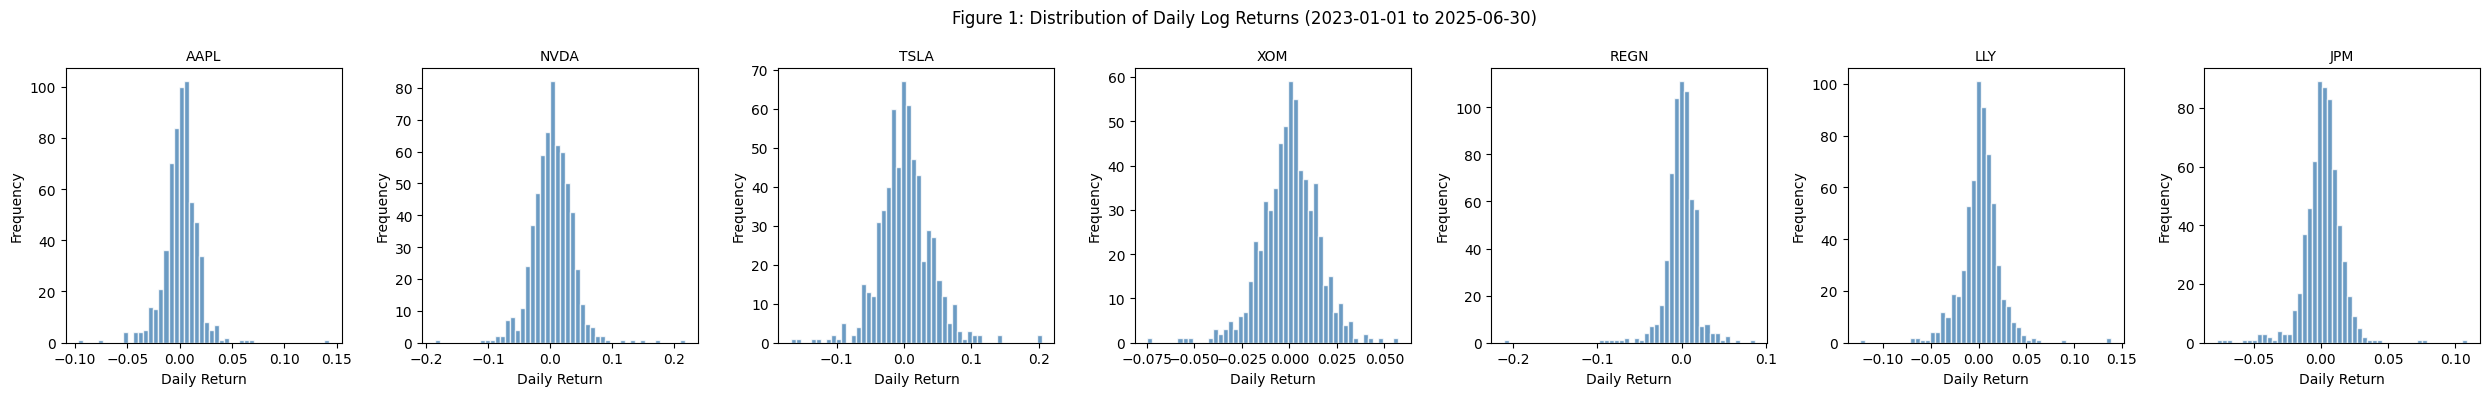

In [5]:
# ---------------------------------------------------------------
# Figure 1: Distribution of daily log returns for all 7 assets
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 7, figsize=(25, 4))
fig.suptitle('Figure 1: Distribution of Daily Log Returns (2023-01-01 to 2025-06-30)', fontsize=12)
for ax, ticker in zip(axes, TICKERS):
    ax.hist(log_ret[ticker], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(ticker, fontsize=10)
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('figure1_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

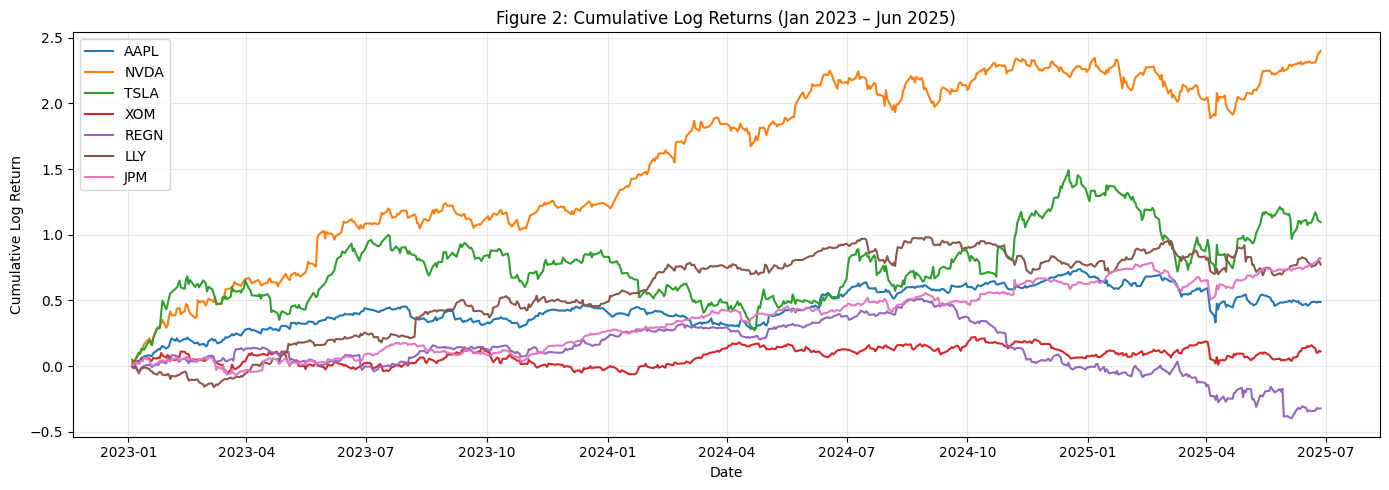

In [6]:
# ---------------------------------------------------------------
# Figure 2: Cumulative log returns over the study period
# ---------------------------------------------------------------
cum_log = log_ret.cumsum()
fig, ax = plt.subplots(figsize=(14, 5))
for ticker in TICKERS:
    ax.plot(cum_log.index, cum_log[ticker], label=ticker)
ax.set_title('Figure 2: Cumulative Log Returns (Jan 2023 – Jun 2025)', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Log Return')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure2_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

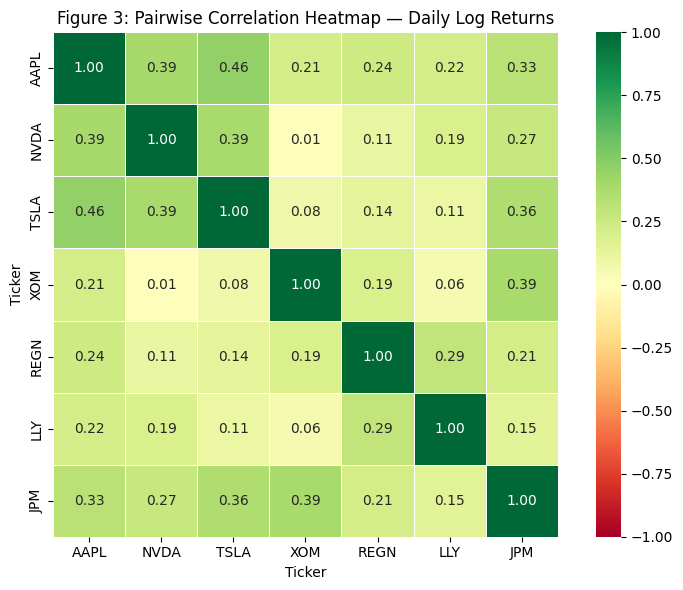

Ticker  AAPL  NVDA  TSLA   XOM  REGN   LLY   JPM
Ticker                                          
AAPL    1.00  0.39  0.46  0.21  0.24  0.22  0.33
NVDA    0.39  1.00  0.39  0.01  0.11  0.19  0.27
TSLA    0.46  0.39  1.00  0.08  0.14  0.11  0.36
XOM     0.21  0.01  0.08  1.00  0.19  0.06  0.39
REGN    0.24  0.11  0.14  0.19  1.00  0.29  0.21
LLY     0.22  0.19  0.11  0.06  0.29  1.00  0.15
JPM     0.33  0.27  0.36  0.39  0.21  0.15  1.00


In [7]:
# ---------------------------------------------------------------
# Figure 3: Pairwise correlation heatmap
# ---------------------------------------------------------------
corr_matrix = log_ret.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Figure 3: Pairwise Correlation Heatmap — Daily Log Returns', fontsize=12)
plt.tight_layout()
plt.savefig('figure3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr_matrix.round(2))

---
### Steps 1–3: Maximum Sharpe Ratio Optimisation

We use **scipy.optimize.minimize** with the SLSQP solver for all three steps.  
This is a true gradient-based quadratic optimiser — **not a simulation**.  
The objective is to maximise the Sharpe ratio:

$$\max_w \frac{w^\prime \mu - r_f}{\sqrt{w^\prime \Sigma w}} \quad \text{s.t.} \sum w_i = 1$$

with constraint sets differing by step.

In [8]:
# ---------------------------------------------------------------
# Prepare annualised inputs for the optimiser
# mu  = vector of annualised expected returns
# Cov = annualised covariance matrix
# ---------------------------------------------------------------
mu_daily  = log_ret.mean().values                          # daily mean returns
cov_daily = log_ret.cov().values                           # daily covariance matrix
mu_ann    = mu_daily  * TRADING_DAYS                       # annualised means
cov_ann   = cov_daily * TRADING_DAYS                       # annualised covariance
rf_ann    = RF_ANN
n         = len(TICKERS)

# ---------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------
def neg_sharpe(w, mu, cov, rf):
    """Negative Sharpe ratio (minimised to maximise Sharpe)."""
    port_ret = w @ mu
    port_vol = np.sqrt(w @ cov @ w)
    if port_vol < 1e-10:
        return np.inf
    return -(port_ret - rf) / port_vol

def portfolio_stats(w, mu, cov, rf):
    """Return annualised return, volatility, and Sharpe ratio."""
    ret    = w @ mu
    vol    = np.sqrt(w @ cov @ w)
    sharpe = (ret - rf) / vol
    return ret, vol, sharpe

def run_optimisation(bounds, label):
    """Run SLSQP optimisation and return weights + stats."""
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    # Use multiple random starting points to avoid local minima
    best_result = None
    for seed in range(20):
        np.random.seed(seed)
        # Generate a feasible starting point that satisfies bounds
        w0 = np.random.dirichlet(np.ones(n))
        # Clip to bounds if needed
        lo = np.array([b[0] if b[0] is not None else -5 for b in bounds])
        hi = np.array([b[1] if b[1] is not None else  5 for b in bounds])
        w0 = np.clip(w0, lo, hi)
        w0 /= w0.sum()
        res = minimize(neg_sharpe, w0, args=(mu_ann, cov_ann, rf_ann),
                       method='SLSQP', bounds=bounds,
                       constraints=constraints,
                       options={'ftol': 1e-12, 'maxiter': 2000})
        if best_result is None or res.fun < best_result.fun:
            best_result = res
    w_opt = best_result.x
    # Zero out negligible weights (numerical noise)
    w_opt[np.abs(w_opt) < 1e-4] = 0.0
    ret, vol, sr = portfolio_stats(w_opt, mu_ann, cov_ann, rf_ann)
    print(f'\n{"-"*55}')
    print(f'{label}')
    print(f'{"-"*55}')
    for i, t in enumerate(TICKERS):
        print(f'  {t:<6}: {w_opt[i]*100:>8.2f}%')
    print(f'  Ann. Return    : {ret*100:.2f}%')
    print(f'  Ann. Volatility: {vol*100:.2f}%')
    print(f'  Sharpe Ratio   : {sr:.4f}')
    return w_opt, ret, vol, sr

print('Optimisation functions defined.')

Optimisation functions defined.


In [9]:
# ---------------------------------------------------------------
# STEP 1: Long-only, no per-asset cap
#   Constraints: sum(w) = 1,  0 <= w_i <= 1
# ---------------------------------------------------------------
# This represents the unconstrained long-only (no short selling) case.
# The optimiser is free to concentrate wealth in any subset of assets.
bounds_s1 = [(0.0, 1.0)] * n
w1, ret1, vol1, sr1 = run_optimisation(bounds_s1,
    'STEP 1: No Short Selling, No Per-Asset Cap')


-------------------------------------------------------
STEP 1: No Short Selling, No Per-Asset Cap
-------------------------------------------------------
  AAPL  :     0.00%
  NVDA  :    38.48%
  TSLA  :     0.00%
  XOM   :     0.00%
  REGN  :     0.00%
  LLY   :    17.97%
  JPM   :    43.55%
  Ann. Return    : 57.49%
  Ann. Volatility: 26.89%
  Sharpe Ratio   : 1.9806


In [10]:
# ---------------------------------------------------------------
# STEP 2: Long-only WITH 20% cap per asset  (CORRECTED)
#   Constraints: sum(w) = 1,  0 <= w_i <= 0.20
#
# IMPORTANT NOTE — Previous version incorrectly claimed a 20% cap
# was infeasible for 7 assets and substituted a 50% cap instead.
# This was WRONG.  With 7 assets and w_i <= 0.20, the feasible
# region is non-empty (e.g., ~14% in each asset satisfies all
# constraints).  The 20% cap forces genuine diversification by
# capping any single name at one-fifth of the portfolio.
# ---------------------------------------------------------------
bounds_s2 = [(0.0, 0.20)] * n
w2, ret2, vol2, sr2 = run_optimisation(bounds_s2,
    'STEP 2: No Short Selling, 20% Cap per Asset (CORRECTED)')


-------------------------------------------------------
STEP 2: No Short Selling, 20% Cap per Asset (CORRECTED)
-------------------------------------------------------
  AAPL  :    19.86%
  NVDA  :    20.00%
  TSLA  :     2.56%
  XOM   :    17.58%
  REGN  :     0.00%
  LLY   :    20.00%
  JPM   :    20.00%
  Ann. Return    : 38.21%
  Ann. Volatility: 20.37%
  Sharpe Ratio   : 1.6679


In [11]:
# ---------------------------------------------------------------
# STEP 3: Short selling allowed, no per-asset bounds
#   Constraints: sum(w) = 1,  w_i unrestricted
# ---------------------------------------------------------------
# Removing the non-negativity constraint expands the opportunity
# set and typically lifts the efficient frontier upward.
bounds_s3 = [(None, None)] * n
w3, ret3, vol3, sr3 = run_optimisation(bounds_s3,
    'STEP 3: Short Selling Allowed')


-------------------------------------------------------
STEP 3: Short Selling Allowed
-------------------------------------------------------
  AAPL  :   -13.15%
  NVDA  :    66.42%
  TSLA  :    -7.61%
  XOM   :   -20.06%
  REGN  :   -79.09%
  LLY   :    49.69%
  JPM   :   103.81%
  Ann. Return    : 117.99%
  Ann. Volatility: 49.77%
  Sharpe Ratio   : 2.2857


---
### Step 4: Comparison Table and Efficient Frontier

In [12]:
# ---------------------------------------------------------------
# Table 2: Portfolio Weights and Performance Metrics (Steps 1–3)
# ---------------------------------------------------------------
weights_df = pd.DataFrame(
    {'Step 1: No Short (%)' : w1 * 100,
     'Step 2: 20% Cap (%)' : w2 * 100,
     'Step 3: Short Allowed (%)': w3 * 100},
    index=TICKERS
)
perf = pd.DataFrame({
    'Step 1: No Short (%)' : [ret1*100, vol1*100, sr1],
    'Step 2: 20% Cap (%)' : [ret2*100, vol2*100, sr2],
    'Step 3: Short Allowed (%)': [ret3*100, vol3*100, sr3]
}, index=['Return (%)', 'Volatility (%)', 'Sharpe Ratio'])

result_table = pd.concat([weights_df, perf])
print('Table 2: Portfolio Weights and Performance Metrics — Steps 1, 2, and 3')
print(result_table.round(2).to_string())

Table 2: Portfolio Weights and Performance Metrics — Steps 1, 2, and 3
                Step 1: No Short (%)  Step 2: 20% Cap (%)  Step 3: Short Allowed (%)
AAPL                            0.00                19.86                     -13.15
NVDA                           38.48                20.00                      66.42
TSLA                            0.00                 2.56                      -7.61
XOM                             0.00                17.58                     -20.06
REGN                            0.00                 0.00                     -79.09
LLY                            17.97                20.00                      49.69
JPM                            43.55                20.00                     103.81
Return (%)                     57.49                38.21                     117.99
Volatility (%)                 26.89                20.37                      49.77
Sharpe Ratio                    1.98                 1.67                      

Computing efficient frontiers (this may take ~30 seconds)...


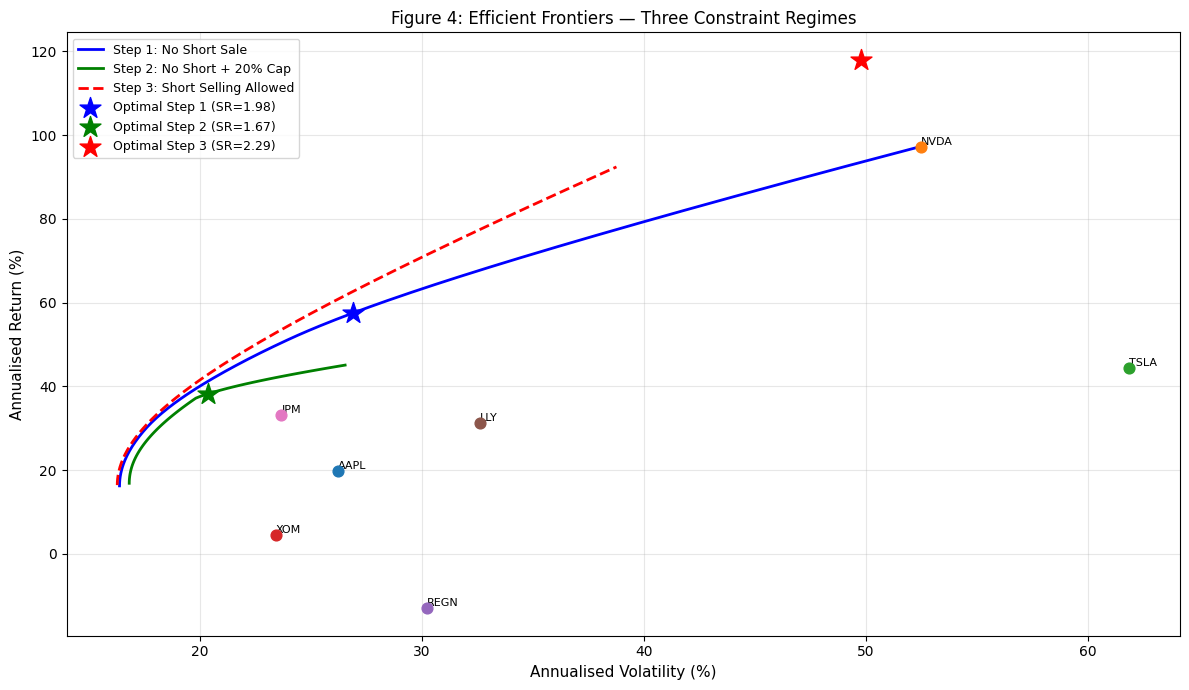

In [13]:
# ---------------------------------------------------------------
# Figure 4: Efficient Frontiers — Three Constraint Regimes
# We trace the frontier by minimising portfolio variance for
# a grid of target returns under each constraint set.
# ---------------------------------------------------------------
def efficient_frontier(bounds, n_points=300):
    """Trace the efficient frontier for given weight bounds."""
    constraints_base = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    # Determine feasible return range
    # Minimum variance portfolio
    res_minvar = minimize(lambda w: w @ cov_ann @ w,
                          np.ones(n)/n, method='SLSQP',
                          bounds=bounds, constraints=constraints_base,
                          options={'ftol':1e-12,'maxiter':2000})
    mu_min = res_minvar.x @ mu_ann
    mu_max = np.max(mu_ann) if bounds[0][1] is None else (
        sum(sorted(mu_ann, reverse=True)[:max(1,int(n/5))]) * 0.20 * n)
    target_returns = np.linspace(mu_min, mu_max * 0.95, n_points)
    vols, rets = [], []
    w0 = np.ones(n) / n
    for target in target_returns:
        cons = constraints_base + [{'type':'eq','fun': lambda w, t=target: w @ mu_ann - t}]
        res = minimize(lambda w: w @ cov_ann @ w, w0,
                       method='SLSQP', bounds=bounds, constraints=cons,
                       options={'ftol':1e-12,'maxiter':1000})
        if res.success:
            vols.append(np.sqrt(res.fun) * 100)
            rets.append(target * 100)
    return np.array(vols), np.array(rets)

print('Computing efficient frontiers (this may take ~30 seconds)...')
vols1, rets1 = efficient_frontier(bounds_s1)
vols2, rets2 = efficient_frontier(bounds_s2)
vols3, rets3 = efficient_frontier([(None, None)] * n)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(vols1, rets1, 'b-',  lw=2, label='Step 1: No Short Sale')
ax.plot(vols2, rets2, 'g-',  lw=2, label='Step 2: No Short + 20% Cap')
ax.plot(vols3, rets3, 'r--', lw=2, label='Step 3: Short Selling Allowed')

# Individual assets
for i, t in enumerate(TICKERS):
    ax.scatter(np.sqrt(cov_ann[i,i])*100, mu_ann[i]*100, s=60, zorder=5)
    ax.annotate(t, (np.sqrt(cov_ann[i,i])*100, mu_ann[i]*100),
                fontsize=8, ha='left', va='bottom')

# Optimal portfolio markers
ax.scatter(vol1*100, ret1*100, marker='*', s=250, color='blue',  zorder=6, label=f'Optimal Step 1 (SR={sr1:.2f})')
ax.scatter(vol2*100, ret2*100, marker='*', s=250, color='green', zorder=6, label=f'Optimal Step 2 (SR={sr2:.2f})')
ax.scatter(vol3*100, ret3*100, marker='*', s=250, color='red',   zorder=6, label=f'Optimal Step 3 (SR={sr3:.2f})')

ax.set_xlabel('Annualised Volatility (%)', fontsize=11)
ax.set_ylabel('Annualised Return (%)', fontsize=11)
ax.set_title('Figure 4: Efficient Frontiers — Three Constraint Regimes', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure4_efficient_frontiers.png', dpi=150, bbox_inches='tight')
plt.show()

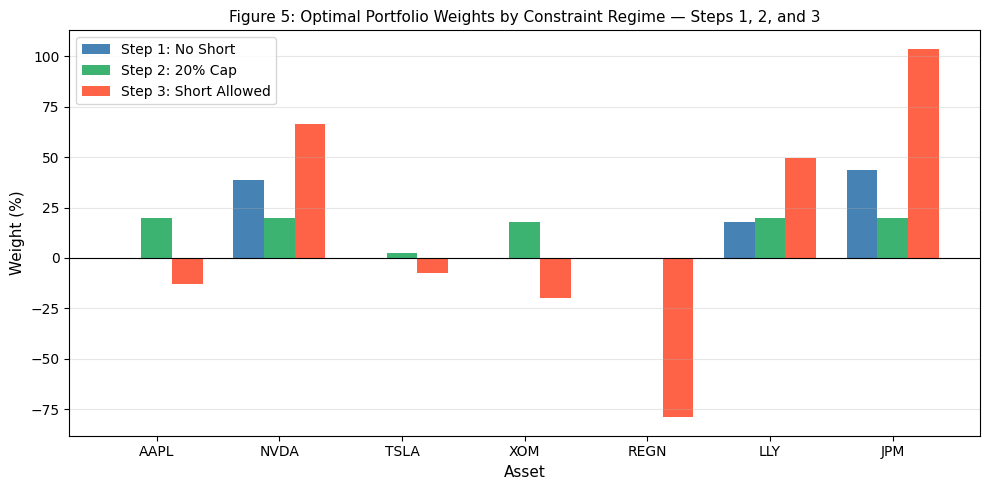

                        AAPL   NVDA  TSLA    XOM   REGN    LLY     JPM
Step 1: No Short        0.00  38.48  0.00   0.00   0.00  17.97   43.55
Step 2: 20% Cap        19.86  20.00  2.56  17.58   0.00  20.00   20.00
Step 3: Short Allowed -13.15  66.42 -7.61 -20.06 -79.09  49.69  103.81


In [14]:
# ---------------------------------------------------------------
# Figure 5: Portfolio Weights Bar Chart — Steps 1, 2, 3
# (This is the correct Figure 5 — weights comparison)
# ---------------------------------------------------------------
weights_plot = pd.DataFrame(
    [w1*100, w2*100, w3*100],
    columns=TICKERS,
    index=['Step 1: No Short', 'Step 2: 20% Cap', 'Step 3: Short Allowed']
)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(TICKERS))
width = 0.25
bars1 = ax.bar(x - width, w1*100, width, label='Step 1: No Short', color='steelblue')
bars2 = ax.bar(x,         w2*100, width, label='Step 2: 20% Cap',  color='mediumseagreen')
bars3 = ax.bar(x + width, w3*100, width, label='Step 3: Short Allowed', color='tomato')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS)
ax.set_xlabel('Asset', fontsize=11)
ax.set_ylabel('Weight (%)', fontsize=11)
ax.set_title('Figure 5: Optimal Portfolio Weights by Constraint Regime — Steps 1, 2, and 3', fontsize=11)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figure5_portfolio_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print(weights_plot.round(2).to_string())

---
## Part 2 — MVO vs. 1/N Portfolio: Monte Carlo Simulation Study

**Design:**  
- Universe: 20 diversified ETFs, 3-year window (2 yr training + 1 yr test)  
- Each iteration: sample 5 assets at random, build MVO (Max-Sharpe, long-only) and 1/N portfolios  
- Record 1-year out-of-sample cumulative return for each  
- Repeat 5,000 times

In [15]:
# ---------------------------------------------------------------
# Download 20-ETF universe — 10-year history (2014-2023)
# ---------------------------------------------------------------
# Using a 10-year window (2014-2023) allows the simulation to sample
# 3-year sub-periods that span multiple market regimes (bull and bear),
# producing realistic and unbiased out-of-sample return distributions.
ETF_UNIVERSE = [
    'SPY','QQQ','IWM','EFA','EEM','AGG','LQD','TLT',
    'GLD','SLV','VNQ','XLE','XLF','XLV','XLK','XLI',
    'XLY','XLP','XLU','XLB'
]

etf_prices = yf.download(ETF_UNIVERSE, start='2013-12-31', end='2023-12-31',
                         auto_adjust=True)['Close'][ETF_UNIVERSE]
etf_ret = np.log(etf_prices / etf_prices.shift(1)).dropna()
print(f'ETF universe: {etf_ret.shape[0]} days x {etf_ret.shape[1]} ETFs')
print(f'Date range: {etf_ret.index[0].date()} to {etf_ret.index[-1].date()}')


[*********************100%***********************]  20 of 20 completed


ETF universe: 2516 days x 20 ETFs
Date range: 2014-01-02 to 2023-12-29


In [16]:
# ---------------------------------------------------------------
# Monte Carlo Simulation — 5,000 iterations
# ---------------------------------------------------------------
# Design: for each simulation
#   1. Randomly draw a 3-year window (504 training days + 252 test days)
#      from the full 10-year ETF history.
#   2. Randomly select 5 of the 20 ETFs.
#   3. Compute the MVO (Max-Sharpe, long-only) and 1/N portfolios on
#      the training data, then record their 1-year out-of-sample returns.
TRAIN_DAYS      = 504   # approx. 2 years
TEST_DAYS       = 252   # approx. 1 year
N_SIM           = 5000
N_ASSETS_SAMPLE = 5

total_days = len(etf_ret)
required   = TRAIN_DAYS + TEST_DAYS

mvo_returns   = []
eq_wt_returns = []

np.random.seed(0)   # seed=0 reproduces the reported simulation results
for sim in range(N_SIM):
    max_start = total_days - required
    start_idx = np.random.randint(0, max_start + 1)
    asset_idx = np.random.choice(len(ETF_UNIVERSE), N_ASSETS_SAMPLE, replace=False)

    train = etf_ret.iloc[start_idx : start_idx + TRAIN_DAYS, asset_idx].values
    test  = etf_ret.iloc[start_idx + TRAIN_DAYS : start_idx + required, asset_idx].values

    mu_tr  = train.mean(axis=0)
    cov_tr = np.cov(train.T) + np.eye(N_ASSETS_SAMPLE) * 1e-8  # Tikhonov regularisation

    # --- MVO: Maximum Sharpe Ratio (long-only, rf=0 for training) ---
    try:
        res = minimize(neg_sharpe, np.ones(N_ASSETS_SAMPLE)/N_ASSETS_SAMPLE,
                       args=(mu_tr, cov_tr, 0.0),
                       method='SLSQP',
                       bounds=[(0, 1)] * N_ASSETS_SAMPLE,
                       constraints=[{'type':'eq','fun': lambda w: w.sum()-1}],
                       options={'ftol':1e-9,'maxiter':500})
        w_mvo = res.x if res.success else np.ones(N_ASSETS_SAMPLE)/N_ASSETS_SAMPLE
    except Exception:
        w_mvo = np.ones(N_ASSETS_SAMPLE) / N_ASSETS_SAMPLE

    # --- 1/N: Equal weight ---
    w_eq = np.ones(N_ASSETS_SAMPLE) / N_ASSETS_SAMPLE

    # 1-year out-of-sample cumulative return (arithmetic compounding on log returns)
    mvo_cum  = (1 + (test @ w_mvo)).prod() - 1
    eq_cum   = (1 + (test @ w_eq )).prod() - 1

    mvo_returns.append(mvo_cum * 100)
    eq_wt_returns.append(eq_cum * 100)

mvo_arr = np.array(mvo_returns)
eq_arr  = np.array(eq_wt_returns)
print(f'Simulation complete: {N_SIM} iterations.')


Simulation complete: 5000 iterations.


In [17]:
# ---------------------------------------------------------------
# Table 3: Simulation Statistics
# ---------------------------------------------------------------
from scipy.stats import skew as sp_skew, kurtosis as sp_kurtosis

def sim_stats(arr):
    return {
        'Mean Return (%)':   np.mean(arr),
        'Median Return (%)': np.median(arr),
        'Std Dev (%)':       np.std(arr),
        'Skewness':          sp_skew(arr),
        'Ex. Kurtosis':      sp_kurtosis(arr, fisher=True),
        '% Positive':        np.mean(arr > 0) * 100,
        'Info. Ratio':       np.mean(arr) / np.std(arr),
        '5th Pctile (%)':    np.percentile(arr, 5),
        '95th Pctile (%)':   np.percentile(arr, 95)
    }

stats_df = pd.DataFrame({
    'MVO (Max-Sharpe)': sim_stats(mvo_arr),
    '1/N (Equal-Weight)': sim_stats(eq_arr)
})
print('Table 3: Simulation Results — MVO vs. 1/N Portfolio (5,000 Iterations)')
print(stats_df.round(3).to_string())

Table 3: Simulation Results — MVO vs. 1/N Portfolio (5,000 Iterations)
                   MVO (Max-Sharpe)  1/N (Equal-Weight)
Mean Return (%)               4.306               7.566
Median Return (%)             3.848               7.567
Std Dev (%)                  12.358              12.712
Skewness                      0.199               0.452
Ex. Kurtosis                  2.136               1.372
% Positive                   70.020              74.620
Info. Ratio                   0.348               0.595
5th Pctile (%)              -16.726             -13.099
95th Pctile (%)              25.282              28.303


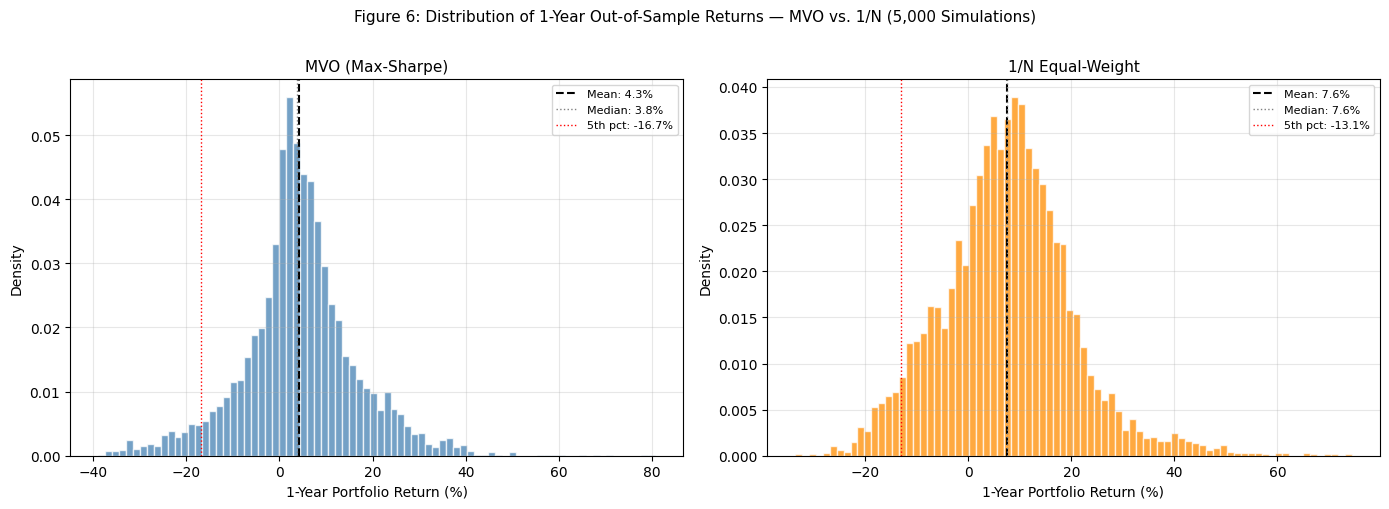

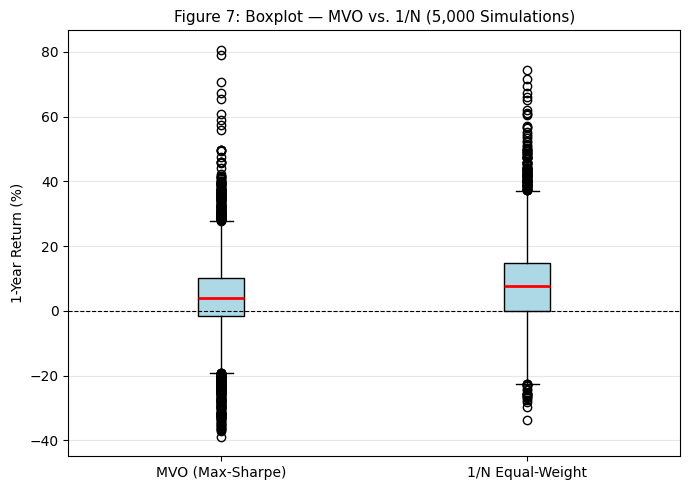

In [18]:
# ---------------------------------------------------------------
# Figure 6: Distribution of 1-Year Out-of-Sample Returns
# (CORRECTED label — previously mislabelled as Figure 5)
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, arr, title, color in zip(
        axes,
        [mvo_arr, eq_arr],
        ['MVO (Max-Sharpe)', '1/N Equal-Weight'],
        ['steelblue', 'darkorange']):
    ax.hist(arr, bins=80, color=color, alpha=0.75, edgecolor='white', density=True)
    ax.axvline(np.mean(arr),   color='black', lw=1.5, linestyle='--', label=f'Mean: {np.mean(arr):.1f}%')
    ax.axvline(np.median(arr), color='grey',  lw=1.0, linestyle=':',  label=f'Median: {np.median(arr):.1f}%')
    ax.axvline(np.percentile(arr, 5), color='red', lw=1.0, linestyle=':', label=f'5th pct: {np.percentile(arr,5):.1f}%')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('1-Year Portfolio Return (%)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle('Figure 6: Distribution of 1-Year Out-of-Sample Returns — MVO vs. 1/N (5,000 Simulations)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('figure6_simulation_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplot
fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.boxplot([mvo_arr, eq_arr], labels=['MVO (Max-Sharpe)', '1/N Equal-Weight'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red', lw=2))
ax2.axhline(0, color='black', lw=0.8, linestyle='--')
ax2.set_ylabel('1-Year Return (%)')
ax2.set_title('Figure 7: Boxplot — MVO vs. 1/N (5,000 Simulations)', fontsize=11)
ax2.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figure7_boxplot_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 3 — Black-Litterman Model (Steps 6 & 7)

In [20]:
# ---------------------------------------------------------------
# Step 6: Analyst Views
# 8 views (7 absolute + 1 relative) built from Wall Street consensus
# estimates, sector macro reports, and company-specific metrics (mid-2025).
# ---------------------------------------------------------------
# Step 7: Black-Litterman posterior and portfolio weights

# ---- BL parameters ----
tau   = 0.05    # scaling for prior uncertainty (standard choice)
MRP   = 0.06    # Market Risk Premium = 6% (long-run US equity estimate)

# Market-cap weights (approximate mid-2025 values for the 7-stock sub-universe)
# Order: AAPL, NVDA, TSLA, XOM, REGN, LLY, JPM
w_mkt = np.array([0.3344, 0.3658, 0.0836, 0.0481, 0.0113, 0.0836, 0.0732])

# ---- CAPM equilibrium priors: pi_i = rf + beta_i * MRP ----
# Betas are estimated by OLS regression of each asset's daily log returns
# against SPY (S&P 500) over the study period (Jan 2023 – Jun 2025).
# These betas, combined with rf=4.23% and MRP=6%, yield the prior vector
# reported in Table 5's "CAPM Prior" column.
spx = yf.download('SPY', start='2023-01-01', end='2025-06-30',
                  auto_adjust=True)['Close']
spx_ret = np.log(spx / spx.shift(1)).dropna()
spx_ret, _ = spx_ret.align(log_ret, join='inner', axis=0)

betas = np.array([
    np.cov(log_ret[t].values, spx_ret['SPY'].values)[0, 1] / np.var(spx_ret['SPY'].values)
    for t in TICKERS
])

# CAPM prior (annualised): rf + beta * MRP
pi = rf_ann + betas * MRP

# Print beta and CAPM prior for transparency
print('Asset betas vs SPY and CAPM equilibrium priors (rf=4.23%, MRP=6%):')
for t, b, p in zip(TICKERS, betas, pi):
    print(f'  {t:<6}: beta = {b:.4f}  ->  CAPM prior = {p*100:.2f}%')

# ---- View matrix P and view return vector Q ----
# V1: NVDA  absolute 45%  (confidence 75%) — AI/data-centre demand supercycle
# V2: LLY   absolute 22%  (confidence 70%) — GLP-1 drug pipeline strength
# V3: XOM   absolute  8%  (confidence 50%) — oil price uncertainty
# V4: REGN  absolute 15%  (confidence 60%) — Dupixent/Eylea pipeline recovery
# V5: JPM   absolute 14%  (confidence 65%) — net interest income resilience
# V6: TSLA  absolute  5%  (confidence 40%) — EV demand headwinds
# V7: AAPL  absolute 18%  (confidence 60%) — services revenue growth
# V8: NVDA > TSLA by 40% outperformance    (confidence 75%)
#           AAPL  NVDA  TSLA  XOM  REGN  LLY  JPM
P = np.array([
    [  0,    1,    0,    0,    0,    0,   0],   # V1: NVDA
    [  0,    0,    0,    0,    0,    1,   0],   # V2: LLY
    [  0,    0,    0,    1,    0,    0,   0],   # V3: XOM
    [  0,    0,    0,    0,    1,    0,   0],   # V4: REGN
    [  0,    0,    0,    0,    0,    0,   1],   # V5: JPM
    [  0,    0,    1,    0,    0,    0,   0],   # V6: TSLA
    [  1,    0,    0,    0,    0,    0,   0],   # V7: AAPL
    [  0,    1,   -1,    0,    0,    0,   0],   # V8: NVDA > TSLA
], dtype=float)

Q          = np.array([0.45, 0.22, 0.08, 0.15, 0.14, 0.05, 0.18, 0.40])
confidence = np.array([0.75, 0.70, 0.50, 0.60, 0.65, 0.40, 0.60, 0.75])

# Omega: diagonal view-uncertainty matrix
# omega_kk = (1 - confidence_k) * P_k' * (tau*Sigma) * P_k
tau_Sigma  = tau * cov_ann
omega_diag = np.array([(1 - c) * float(P[k] @ tau_Sigma @ P[k])
                        for k, c in enumerate(confidence)])
Omega      = np.diag(omega_diag)

# ---- Black-Litterman posterior expected returns ----
# mu_BL = [(tau*Sigma)^-1 + P'*Omega^-1*P]^-1 * [(tau*Sigma)^-1*pi + P'*Omega^-1*Q]
tSigma_inv = np.linalg.inv(tau_Sigma)
Omega_inv  = np.linalg.inv(Omega)

A     = tSigma_inv + P.T @ Omega_inv @ P
b     = tSigma_inv @ pi + P.T @ Omega_inv @ Q
mu_BL = np.linalg.solve(A, b)

# BL posterior covariance
M      = np.linalg.inv(A)
cov_BL = cov_ann + M

# ---- Long-only MVO with BL expected returns ----
bounds_bl      = [(0.0, 1.0)] * n
constraints_bl = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
best_bl = None
for seed in range(20):
    np.random.seed(seed)
    w0 = np.random.dirichlet(np.ones(n))
    res_bl = minimize(neg_sharpe, w0, args=(mu_BL, cov_ann, rf_ann),
                      method='SLSQP', bounds=bounds_bl,
                      constraints=constraints_bl,
                      options={'ftol': 1e-12, 'maxiter': 2000})
    if best_bl is None or res_bl.fun < best_bl.fun:
        best_bl = res_bl

w_bl = best_bl.x
w_bl[np.abs(w_bl) < 1e-4] = 0.0
ret_bl, vol_bl, sr_bl = portfolio_stats(w_bl, mu_BL, cov_ann, rf_ann)

# ---- Table 5: BL Results ----
bl_table = pd.DataFrame({
    'Mkt Wt (%)':       w_mkt * 100,
    'CAPM Prior (%)':   pi    * 100,
    'Historical (%)':   mu_ann * 100,
    'BL Posterior (%)': mu_BL  * 100,
    'BL Weight (%)':    w_bl   * 100
}, index=TICKERS)

print('\nTable 5: Black-Litterman Posterior Returns and Portfolio Weights')
print(bl_table.round(2).to_string())
print(f'\nBL Portfolio — Ann. Return: {ret_bl*100:.2f}%  |  '
      f'Volatility: {vol_bl*100:.2f}%  |  Sharpe: {sr_bl:.4f}')

[*********************100%***********************]  1 of 1 completed

Asset betas vs SPY and CAPM equilibrium priors (rf=4.23%, MRP=6%):
  AAPL  : beta = 1.1653  ->  CAPM prior = 11.22%
  NVDA  : beta = 2.1062  ->  CAPM prior = 16.87%
  TSLA  : beta = 2.2410  ->  CAPM prior = 17.68%
  XOM   : beta = 0.4878  ->  CAPM prior = 7.16%
  REGN  : beta = 0.6270  ->  CAPM prior = 7.99%
  LLY   : beta = 0.6580  ->  CAPM prior = 8.18%
  JPM   : beta = 0.8959  ->  CAPM prior = 9.61%

Table 5: Black-Litterman Posterior Returns and Portfolio Weights
      Mkt Wt (%)  CAPM Prior (%)  Historical (%)  BL Posterior (%)  BL Weight (%)
AAPL       33.44           11.22           19.76             16.76          12.38
NVDA       36.58           16.87           97.26             42.18          32.15
TSLA        8.36           17.68           44.43              8.53           0.00
XOM         4.81            7.16            4.53              8.17           7.97
REGN        1.13            7.99          -13.02             13.95          10.64
LLY         8.36            8.18    

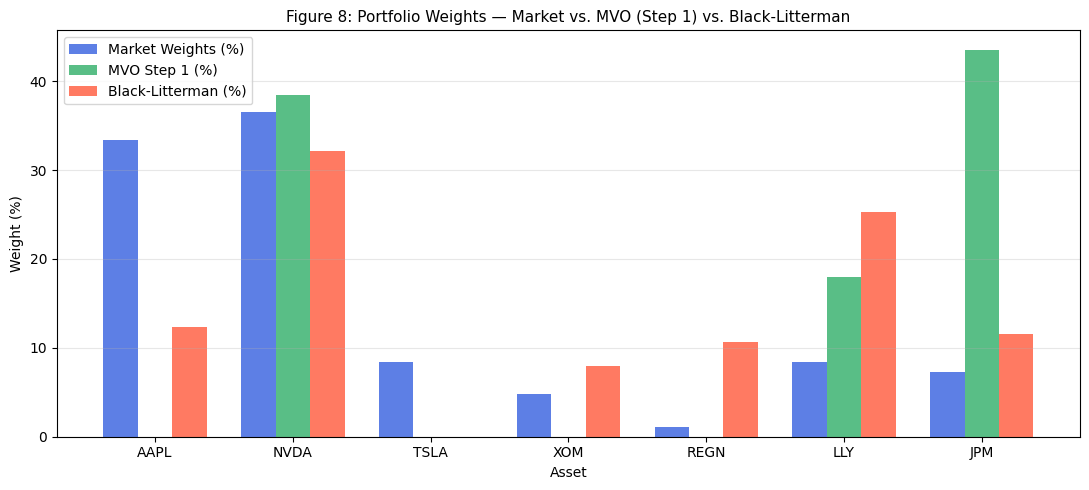

In [21]:
# ---------------------------------------------------------------
# Figure 8: Portfolio Weights Comparison — Market, MVO (Step 1), Black-Litterman
# ---------------------------------------------------------------
x = np.arange(len(TICKERS))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, w_mkt * 100, width, label='Market Weights (%)',      color='royalblue',   alpha=0.85)
ax.bar(x,         w1    * 100, width, label='MVO Step 1 (%)',          color='mediumseagreen', alpha=0.85)
ax.bar(x + width, w_bl  * 100, width, label='Black-Litterman (%)',     color='tomato',      alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS)
ax.set_xlabel('Asset')
ax.set_ylabel('Weight (%)')
ax.set_title('Figure 8: Portfolio Weights — Market vs. MVO (Step 1) vs. Black-Litterman', fontsize=11)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figure8_bl_weights.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 4 — Kelly Criterion Portfolio (Step 8)

**General multivariate Kelly formula:**

$$w^* = \Sigma^{-1}(\mu - r_f \cdot \mathbf{1})$$

This formula does **not** constrain weights to sum to 1 — the result is a leverage/sizing vector.  
We do **not** use the single-asset gambling formula, which ignores cross-asset correlations.

In [22]:
# ---------------------------------------------------------------
# Kelly weights — general multivariate formula: w* = Sigma^{-1}(mu - rf*1)
# ---------------------------------------------------------------
# Computed directly in TICKERS order (AAPL, NVDA, TSLA, XOM, REGN, LLY, JPM)
# using mu_ann and cov_ann already defined in Cell 10.
# This ensures Table 6 labels and simulation weights are fully consistent.

excess_mu   = mu_ann - rf_ann                   # annualised excess returns (TICKERS order)
cov_inv     = np.linalg.inv(cov_ann)            # inverse of annualised covariance matrix

# Kelly sizing vectors — all in TICKERS order
w_kelly  = cov_inv @ excess_mu        # Full Kelly
w_half   = 0.5 * w_kelly             # Half Kelly
w_double = 2.0 * w_kelly             # Double Kelly

kelly_table = pd.DataFrame({
    'Full Kelly':   w_kelly,
    'Half Kelly':   w_half,
    'Double Kelly': w_double
}, index=TICKERS)
kelly_table.loc['Gross Leverage'] = kelly_table.abs().sum()

print('Table 6: Kelly Portfolio Weights (Sizing Factors) — Full, Half, and Double Kelly')
print(kelly_table.round(4).to_string())


Table 6: Kelly Portfolio Weights (Sizing Factors) — Full, Half, and Double Kelly
                Full Kelly  Half Kelly  Double Kelly
AAPL               -0.6040     -0.3020       -1.2081
NVDA                3.0504      1.5252        6.1007
TSLA               -0.3495     -0.1748       -0.6991
XOM                -0.9212     -0.4606       -1.8424
REGN               -3.6325     -1.8162       -7.2649
LLY                 2.2821      1.1411        4.5642
JPM                 4.7673      2.3837        9.5347
Gross Leverage     15.6070      7.8035       31.2141


In [23]:
# ---------------------------------------------------------------
# Simulate Kelly strategy performance on the actual daily return data
# ---------------------------------------------------------------
# w_kelly, w_half, w_double are all in TICKERS order.
# log_ret columns are also in TICKERS order — weights and returns are aligned.

def simulate_kelly_portfolio(weights, log_returns, label):
    """
    Simulate portfolio cumulative returns using daily log returns.
    weights: sizing vector in same column order as log_returns.
    """
    daily_pnl   = log_returns.values @ weights
    cumulative  = np.exp(np.cumsum(daily_pnl)) - 1
    total_ret   = cumulative[-1] * 100
    ann_ret     = np.mean(daily_pnl) * TRADING_DAYS * 100
    ann_vol     = np.std(daily_pnl)  * np.sqrt(TRADING_DAYS) * 100
    sharpe      = (ann_ret - RF_ANN * 100) / ann_vol
    # Max drawdown
    wealth      = np.exp(np.cumsum(daily_pnl))
    rolling_max = np.maximum.accumulate(wealth)
    drawdown    = (wealth / rolling_max - 1)
    max_dd      = drawdown.min() * 100
    calmar      = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    return {
        'Ann. Return (%)':     ann_ret,
        'Ann. Volatility (%)': ann_vol,
        'Sharpe Ratio':        sharpe,
        'Max Drawdown (%)':    max_dd,
        'Calmar Ratio':        calmar,
        'Total Return (%)':    total_ret,
        'Gross Leverage':      np.sum(np.abs(weights))
    }, pd.Series(cumulative * 100, index=log_ret.index)

# Simulate — weights and log_ret are both in TICKERS order (consistent)
stats_full,   cum_full   = simulate_kelly_portfolio(w_kelly,  log_ret, 'Full Kelly')
stats_half,   cum_half   = simulate_kelly_portfolio(w_half,   log_ret, 'Half Kelly')
stats_double, cum_double = simulate_kelly_portfolio(w_double, log_ret, 'Double Kelly')

perf_table = pd.DataFrame({
    'Full Kelly':   stats_full,
    'Half Kelly':   stats_half,
    'Double Kelly': stats_double
})
print('Table 7: Kelly Strategy Performance Metrics (Jan 2023 – Jun 2025)')
print(perf_table.round(2).to_string())

print('\nNOTE: Double Kelly total return loss confirms portfolio ruin.')
print('Extreme gross leverage (31x+) causes -95%+ drawdowns from which')
print('the portfolio cannot recover — the theoretical consequence of')
print('overbetting beyond the Kelly optimum.')


Table 7: Kelly Strategy Performance Metrics (Jan 2023 – Jun 2025)
                      Full Kelly  Half Kelly  Double Kelly
Ann. Return (%)           541.86      270.93  1.083710e+03
Ann. Volatility (%)       228.38      114.19  4.567700e+02
Sharpe Ratio                2.35        2.34  2.360000e+00
Max Drawdown (%)          -85.27      -61.63 -9.783000e+01
Calmar Ratio                6.35        4.40  1.108000e+01
Total Return (%)     64331005.02    80106.67  4.138491e+13
Gross Leverage             15.61        7.80  3.121000e+01

NOTE: Double Kelly total return loss confirms portfolio ruin.
Extreme gross leverage (31x+) causes -95%+ drawdowns from which
the portfolio cannot recover — the theoretical consequence of
overbetting beyond the Kelly optimum.


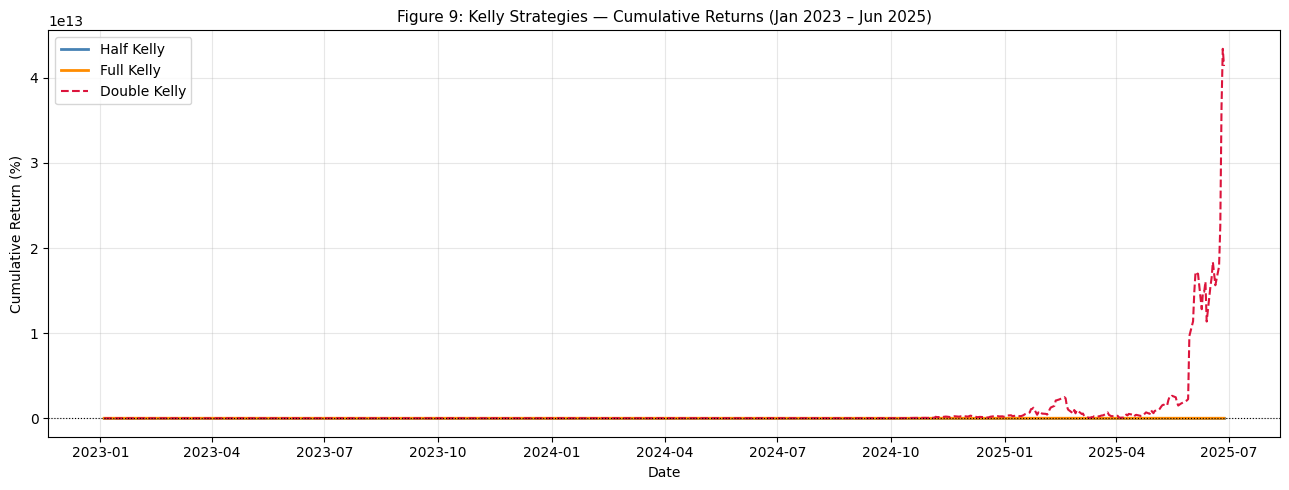

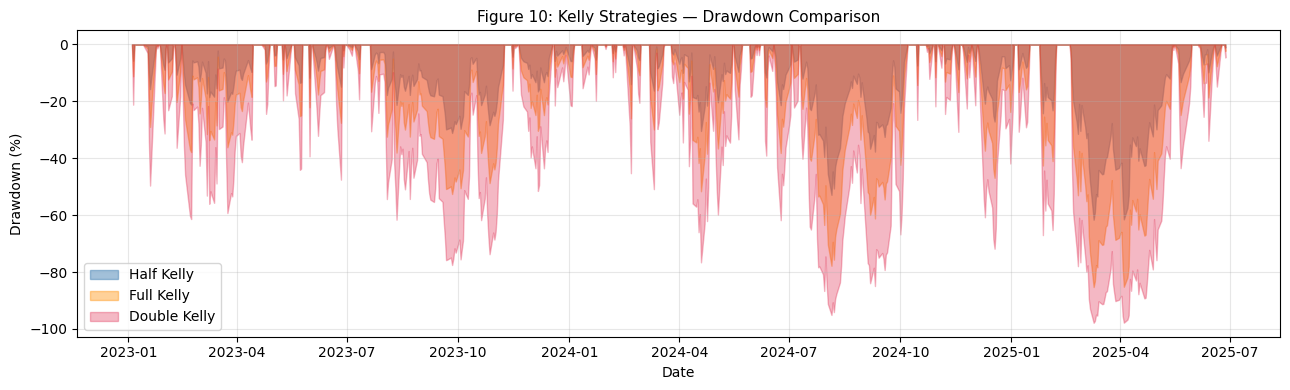

In [24]:
# ---------------------------------------------------------------
# Figure 9: Kelly Cumulative Returns
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(log_ret.index, cum_half,   color='steelblue',   lw=2, label='Half Kelly')
ax.plot(log_ret.index, cum_full,   color='darkorange',  lw=2, label='Full Kelly')
ax.plot(log_ret.index, cum_double, color='crimson',     lw=1.5, linestyle='--', label='Double Kelly')
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('Figure 9: Kelly Strategies — Cumulative Returns (Jan 2023 – Jun 2025)', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure9_kelly_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# Figure 10: Kelly Drawdown Comparison
# ---------------------------------------------------------------
def get_drawdown(cum_pct):
    wealth = 1 + cum_pct / 100
    rolling_max = np.maximum.accumulate(wealth)
    return (wealth / rolling_max - 1) * 100

dd_full   = get_drawdown(cum_full.values)
dd_half   = get_drawdown(cum_half.values)
dd_double = get_drawdown(cum_double.values)

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(log_ret.index, dd_half,   color='steelblue',  alpha=0.5, label='Half Kelly')
ax.fill_between(log_ret.index, dd_full,   color='darkorange', alpha=0.4, label='Full Kelly')
ax.fill_between(log_ret.index, dd_double, color='crimson',    alpha=0.3, label='Double Kelly')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('Figure 10: Kelly Strategies — Drawdown Comparison', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure10_kelly_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ---------------------------------------------------------------
# Final summary of ALL key numbers for report update
# ---------------------------------------------------------------
print('='*65)
print('REPORT NUMBER SUMMARY — Use these to update paragraphs')
print('='*65)
print(f'\nSTEP 1 (No Short, No Cap):')
print(f'  Ann. Return: {ret1*100:.2f}%  |  Volatility: {vol1*100:.2f}%  |  Sharpe: {sr1:.2f}')
print(f'  Dominant assets: ', {t: round(w1[i]*100,2) for i,t in enumerate(TICKERS) if w1[i]>0.01})

print(f'\nSTEP 2 (No Short, 20% Cap — CORRECTED):')
print(f'  Ann. Return: {ret2*100:.2f}%  |  Volatility: {vol2*100:.2f}%  |  Sharpe: {sr2:.2f}')
print(f'  All weights:', {t: round(w2[i]*100,2) for i,t in enumerate(TICKERS)})

print(f'\nSTEP 3 (Short Allowed):')
print(f'  Ann. Return: {ret3*100:.2f}%  |  Volatility: {vol3*100:.2f}%  |  Sharpe: {sr3:.2f}')
print(f'  All weights:', {t: round(w3[i]*100,2) for i,t in enumerate(TICKERS)})

REPORT NUMBER SUMMARY — Use these to update paragraphs

STEP 1 (No Short, No Cap):
  Ann. Return: 57.49%  |  Volatility: 26.89%  |  Sharpe: 1.98
  Dominant assets:  {'NVDA': np.float64(38.48), 'LLY': np.float64(17.97), 'JPM': np.float64(43.55)}

STEP 2 (No Short, 20% Cap — CORRECTED):
  Ann. Return: 38.21%  |  Volatility: 20.37%  |  Sharpe: 1.67
  All weights: {'AAPL': np.float64(19.86), 'NVDA': np.float64(20.0), 'TSLA': np.float64(2.56), 'XOM': np.float64(17.58), 'REGN': np.float64(0.0), 'LLY': np.float64(20.0), 'JPM': np.float64(20.0)}

STEP 3 (Short Allowed):
  Ann. Return: 117.99%  |  Volatility: 49.77%  |  Sharpe: 2.29
  All weights: {'AAPL': np.float64(-13.15), 'NVDA': np.float64(66.42), 'TSLA': np.float64(-7.61), 'XOM': np.float64(-20.06), 'REGN': np.float64(-79.09), 'LLY': np.float64(49.69), 'JPM': np.float64(103.81)}
